# Demo

The purpose of this notebook is to demonstrate the functionality of `gliderflightOG1`.

The demo is organised to show

- Step 1: Regressing the Seaglider steady flight model for chosen parameters

- Step 2: Recalculating the glider flight using the flight model and chosen parameters



In [26]:

import xarray as xr
from gliderflightOG1 import plotters, tools
import numpy as np
from gliderflightOG1 import seaglider  # Assuming correct project style

import matplotlib.pyplot as plt

import importlib
importlib.reload(seaglider)

<module 'gliderflightOG1.seaglider' from '/Users/xmiram/gliderflightOG1/gliderflightOG1/seaglider.py'>

In [27]:
### create function that interpolate a variable in order to fill in nan values
def interpolate_over_nans(ds, var_name, method="linear"):
    ds = ds.copy()  # avoid modifying original dataset
    var = ds[var_name]
    ds[var_name] = var.interpolate_na(dim = "N_MEASUREMENTS", method=method)
    return ds

def assign_var_with_mask(ds, var_name, var_values, mask):
    ds = ds.copy()
    full_array = np.full(ds.sizes['N_MEASUREMENTS'], np.nan)
    full_array[mask] = var_values
    ds[var_name] = (('N_MEASUREMENTS',), full_array)
    return ds


def print_profile_diffs(ds, vars_to_print=("PITCH", "TEMP"), n=20, position="beginning", profiles = None):
    """
    Print timestamps, time differences, and selected variables for each profile.

    Parameters
    ----------
    ds : xarray.Dataset
    vars_to_print : list/tuple of str
        Variables to print (e.g., ["PITCH", "TEMP"])
    n : int
        Number of samples per profile
    position : str
        "beginning", "end", or "middle" — where to select the n points
    """

    import numpy as np

    if profiles is None:
        profiles = np.unique(ds.PROFILE_NUMBER.values)

    elif isinstance(profiles, int):
        profiles = [profiles]

    else:
        print("Warning: profiles should be an int or list of ints. Using all profiles.")
        profiles = np.unique(ds.PROFILE_NUMBER.values)

    for profile in profiles:
        print(f"\nProfile {profile}:")

        # mask for this profile
        profile_msk = ds.PROFILE_NUMBER.values == profile

        # timestamps → numeric int64 (ns)
        ts = ds.TIME.values[profile_msk].astype("datetime64[ns]").astype("int64")

        L = len(ts)

        # --- choose region ---
        if position == "beginning":
            idx = slice(0, min(n, L))

        elif position == "end":
            idx = slice(max(0, L - n), L)

        elif position == "middle":
            if n >= L:
                idx = slice(0, L)
            else:
                mid = L // 2
                half = n // 2
                start = max(0, mid - half)
                end = min(L, start + n)
                idx = slice(start, end)

        else:
            raise ValueError("position must be 'beginning', 'end', or 'middle'")

        # selected timestamps
        ts_sel = ts[idx]

        # compute Δt (ns → s)
        diff_seconds = np.diff(ts_sel) * 1e-9

        # collect selected variable data (aligned with diff → skip first)
        var_data = {}
        for var in vars_to_print:
            var_values = ds[var].values[profile_msk][idx]
            var_data[var] = var_values[1:]

        # print header
        header = f"{'t datetime[ns]':<29} | {'Δt [s]':>10}"
        for var in vars_to_print:
            header += f" | {var:>10}"
        print(header)
        print("-" * len(header))

        # rows
        for i, dt in enumerate(diff_seconds):
            t = ts_sel[i + 1].astype("datetime64[ns]")
            row = f"{str(t):<29} | {dt:10.4f}"

            for var in vars_to_print:
                val = var_data[var][i]
                try:
                    row += f" | {float(val):10.4f}"
                except Exception:
                    row += f" | {str(val):>10}"

            print(row)

In [28]:
# 1. Load your dataset
#dataset_path = '../data/sg014_20080214T220104_delayed.nc'
#dataset_path = '../data/sg271_pycnmix_demo.nc'
#dataset_path = '/Users/u302042/Desktop/Master_thesis/Data/Glider/005/20080606/sg005_IFR_demo.nc'
dataset_path = '/Users/xmiram/gliderflightOG1/data/sg271_pycnmix_demo.nc'
glider = xr.open_dataset(dataset_path)


In [29]:
glider

<xarray.Dataset> Size: 376MB
Dimensions:                              (N_MEASUREMENTS: 1161230)
Coordinates:
    TIME                                 (N_MEASUREMENTS) datetime64[ns] 9MB ...
    DEPTH                                (N_MEASUREMENTS) float64 9MB ...
    LATITUDE                             (N_MEASUREMENTS) float64 9MB ...
    LONGITUDE                            (N_MEASUREMENTS) float64 9MB ...
Dimensions without coordinates: N_MEASUREMENTS
Data variables: (12/75)
    PRES_QC                              (N_MEASUREMENTS) float32 5MB ...
    TEMP_RAW_QC                          (N_MEASUREMENTS) float32 5MB ...
    CNDC_RAW_QC                          (N_MEASUREMENTS) float32 5MB ...
    PSAL_RAW_QC                          (N_MEASUREMENTS) float32 5MB ...
    TEMP_QC                              (N_MEASUREMENTS) float32 5MB ...
    CNDC_QC                              (N_MEASUREMENTS) float32 5MB ...
    ...                                   ...
    PLATFORM_MODEL                       <U44 176B ...
    WMO_IDENTIFIER                       <U7 28B ...
    TRAJECTORY                           <U21 84B ...
    DEPLOYMENT_LATITUDE                  float64 8B ...
    DEPLOYMENT_LONGITUDE                 float64 8B ...
    DEPLOYMENT_TIME                      datetime64[ns] 8B ...
Attributes: (12/36)
    title:                                      OceanGliders trajectory file
    id:                                         sg271_20260302T194156_delayed
    platform:                                   sub-surface gliders
    platform_vocabulary:                        https://vocab.nerc.ac.uk/coll...
    naming_authority:                           edu.washington.apl
    geospatial_lat_min:                         -73.02957782591744
    ...                                         ...
    Conventions:                                CF-1.10,OG-1.0
    date_modified:                              20260528T162135
    keywords_vocabulary:                        NASA/GCMD Earth Science Keywo...
    keywords:                                   Water Temperature, Conductivi...
    file_version:                               2.71
    contributer_email:                          null@null.com

In [30]:
# 2. Rename and clean up fields as needed
if "VBD" not in glider.data_vars and "VBD_CC" in glider.data_vars:
    glider = glider.rename({
        'VBD_CC': 'VBD',
    })
if "DIVENUM" not in glider.data_vars:
    if "DIVE_NUMBER" in glider.data_vars:
        dive_str = "DIVE_NUMBER"
    if "divenum" in glider.data_vars:
        dive_str = "divenum"
    glider = glider.rename({
        dive_str: 'DIVENUM',
    })
if "C_VBD" not in glider.data_vars:
    c_vbd = np.full_like(glider.VBD.values, 1000)
    glider['C_VBD'] = (('N_MEASUREMENTS',), c_vbd)

In [31]:
# 3. Add missing variables and interpolate over NaNs if needed


# a) Calculate vertical speed from dz/dt if needed and assign to original dataset
msk = ~np.isnan(glider["PRES"])
glider_new = glider.sel(N_MEASUREMENTS=msk)

glider_new = tools.calc_w_meas(glider_new, depth_var="DEPTH")  # Ensure DEPTH_Z is calculated and used for w_meas
### change GLIDER_VERT_VELO_DZDT units to cm/s 
glider_new['GLIDER_VERT_VELO_DZDT'] = -glider_new['GLIDER_VERT_VELO_DZDT'] * 100  # Convert m/s to cm/s
glider_new['GLIDER_VERT_VELO_MODEL'].assign_attrs(units='cm/s')  # Update units attribute
### add new variable to dataset:
glider = assign_var_with_mask(glider, 'GLIDER_VERT_VELO_DZDT', glider_new['GLIDER_VERT_VELO_DZDT'].values, msk)


# b) Interpolate over NaNs in VBD and PITCH
glider = interpolate_over_nans(glider, 'VBD')
glider = interpolate_over_nans(glider, 'PITCH')


# c) Create UPDN from PITCH
glider = glider.assign_coords(TIME=glider['TIME'])  # Make sure TIME is coordinate
glider['UPDN'] = xr.where(glider['PROFILE_NUMBER']%2 == 1, -1, 1)

In [33]:

print_profile_diffs(glider, vars_to_print=["VBD","PITCH", "TEMP","PRES","PSAL","GLIDE_SPEED","DEPTH","GLIDER_VERT_VELO_DZDT"], n=1000, position="beginning",profiles = 1)


Profile 1:
t datetime[ns]                |     Δt [s] |        VBD |      PITCH |       TEMP |       PRES |       PSAL | GLIDE_SPEED |      DEPTH | GLIDER_VERT_VELO_DZDT
--------------------------------------------------------------------------------------------------------------------------------------------------------------
2026-03-02T19:41:26.000000000 |   178.0000 |        nan |        nan |        nan |        nan |        nan |        nan |     0.0000 |        nan
2026-03-02T19:42:07.665999872 |    41.6660 |   536.6218 |   -44.6000 |        nan |        nan |        nan |        nan |        nan |        nan
2026-03-02T19:42:10.101999872 |     2.4360 |   534.5853 |   -42.6375 |        nan |        nan |        nan |        nan |        nan |        nan
2026-03-02T19:42:10.620999936 |     0.5190 |   532.5488 |   -40.6750 |        nan |        nan |        nan |        nan |        nan |        nan
2026-03-02T19:42:10.898000128 |     0.2770 |   530.5123 |   -38.7125 |    -0.8720 

In [34]:
from gliderflightOG1 import new_flightmodel as nfm
importlib.reload(nfm)

<module 'gliderflightOG1.new_flightmodel' from '/Users/xmiram/gliderflightOG1/gliderflightOG1/new_flightmodel.py'>

In [35]:
params = nfm.FlightParameters()
params.hd_a = glider['HD_A'].mean().values
params.hd_b = glider['HD_B'].mean().values
params.hd_c = glider['HD_C'].mean().values
#params.c_vbd = glider['C_VBD'].values
params.vbdbias = glider['VBD_BIAS'].mean().values
params.vbd_min_cnts = glider['VBD_MIN_CNTS'].values
params.vbd_cnts_per_cc = 1/glider['VBD_CC_PER_CNTS'].values
params.volmax = glider.VOLMAX.values
params.mass = glider.MASS.values

params.temp_ref = 10.0
params.rho0 = 1027.5

fm = nfm.SteadyFlightModel(params=params)


In [36]:
fm.params

FlightParameters(hd_a=array(0.00411147), hd_b=array(0.01250855), hd_c=array(5.7e-06), xl=1.8, mass=array(72.867), volmax=array(71497.40141147), rho0=1027.5, vbd_bias=0.0, vbd_min_cnts=array(500), vbd_cnts_per_cc=np.float64(-4.076641014131309), temp_ref=10.0, therm_exp=7.05e-05, abs_compress=4.1e-06, tol=0.001, max_iter=15)

In [37]:
params = nfm.FlightParameters()
params.hd_a = glider['HD_A'].mean().values
params.hd_b = glider['HD_B'].mean().values
params.hd_c = glider['HD_C'].mean().values
#params.c_vbd = glider['C_VBD'].values
params.vbdbias = glider['VBD_BIAS'].mean().values
params.vbd_min_cnts = glider['VBD_MIN_CNTS'].values
params.vbd_cnts_per_cc = 1/glider['VBD_CC_PER_CNTS'].values
params.volmax = glider.VOLMAX.values
params.mass = glider.MASS.values

params.temp_ref = 10.0
params.rho0 = 1027.5

fm = nfm.SteadyFlightModel(params=params)

In [38]:
msk = ~np.isnan(glider["PRES"])
ds = glider.sel(N_MEASUREMENTS=msk)

In [39]:
fm.solve_model(ds , which_par= np.array([1,1,1,1,1,0]))

INFO:gliderflightOG1.new_flightmodel:🚁 Starting Glider Flight Model Parameter Optimization
INFO:gliderflightOG1.new_flightmodel:============================================================
INFO:gliderflightOG1.new_flightmodel:🔍 Initial Parameter Values:
INFO:gliderflightOG1.new_flightmodel:  hd_a: 0.0041114743488956775
INFO:gliderflightOG1.new_flightmodel:  hd_b: 0.012508551133998718
INFO:gliderflightOG1.new_flightmodel:  vbd_bias: 0.0
INFO:gliderflightOG1.new_flightmodel:  abs_compress: 4.1e-06
INFO:gliderflightOG1.new_flightmodel:  therm_exp: 7.05e-05
INFO:gliderflightOG1.new_flightmodel:  hd_c: 5.7e-06
INFO:gliderflightOG1.new_flightmodel:
The following parameters will be optimized:
INFO:gliderflightOG1.new_flightmodel:  hd_a
INFO:gliderflightOG1.new_flightmodel:  hd_b
INFO:gliderflightOG1.new_flightmodel:  vbd_bias
INFO:gliderflightOG1.new_flightmodel:  abs_compress
INFO:gliderflightOG1.new_flightmodel:  therm_exp
INFO:gliderflightOG1.new_flightmodel:🔄 Iteration 001 | Cost: 9.31078

Optimization terminated successfully.
         Current function value: 0.490130
         Iterations: 71
         Function evaluations: 112


<xarray.Dataset> Size: 124MB
Dimensions:                              (N_MEASUREMENTS: 364260)
Coordinates:
    TIME                                 (N_MEASUREMENTS) datetime64[ns] 3MB ...
    DEPTH                                (N_MEASUREMENTS) float64 3MB 0.1861 ...
    LATITUDE                             (N_MEASUREMENTS) float64 3MB -72.98 ...
    LONGITUDE                            (N_MEASUREMENTS) float64 3MB 171.4 ....
Dimensions without coordinates: N_MEASUREMENTS
Data variables: (12/77)
    PRES_QC                              (N_MEASUREMENTS) float32 1MB ...
    TEMP_RAW_QC                          (N_MEASUREMENTS) float32 1MB ...
    CNDC_RAW_QC                          (N_MEASUREMENTS) float32 1MB ...
    PSAL_RAW_QC                          (N_MEASUREMENTS) float32 1MB ...
    TEMP_QC                              (N_MEASUREMENTS) float32 1MB ...
    CNDC_QC                              (N_MEASUREMENTS) float32 1MB ...
    ...                                   ...
    TRAJECTORY                           <U21 84B ...
    DEPLOYMENT_LATITUDE                  float64 8B ...
    DEPLOYMENT_LONGITUDE                 float64 8B ...
    DEPLOYMENT_TIME                      datetime64[ns] 8B ...
    GLIDER_VERT_VELO_DZDT                (N_MEASUREMENTS) float64 3MB -1.673 ...
    UPDN                                 (N_MEASUREMENTS) int64 3MB -1 -1 ... 1
Attributes: (12/36)
    title:                                      OceanGliders trajectory file
    id:                                         sg271_20260302T194156_delayed
    platform:                                   sub-surface gliders
    platform_vocabulary:                        https://vocab.nerc.ac.uk/coll...
    naming_authority:                           edu.washington.apl
    geospatial_lat_min:                         -73.02957782591744
    ...                                         ...
    Conventions:                                CF-1.10,OG-1.0
    date_modified:                              20260528T162135
    keywords_vocabulary:                        NASA/GCMD Earth Science Keywo...
    keywords:                                   Water Temperature, Conductivi...
    file_version:                               2.71
    contributer_email:                          null@null.com

In [40]:
importlib.reload(nfm)
umag, theta = fm.compute_flight_speed(ds)
vert_speed = umag * np.sin(np.radians(theta))

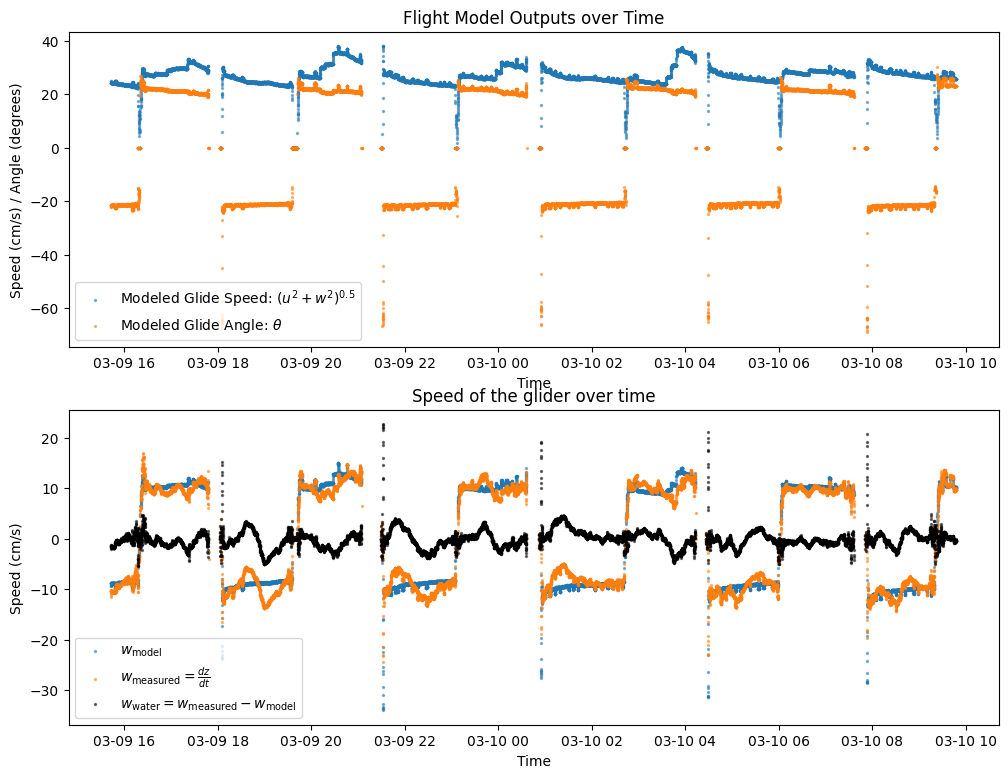

In [41]:
dzdt = ds.GLIDER_VERT_VELO_DZDT.values
sel = slice(200000, 215000)

fig, ax = plt.subplots(2,1,figsize=(12, 9))
ax[0].scatter(ds['TIME'][sel], umag[sel], label=r'Modeled Glide Speed: $(u^2 + w^2)^{0.5}$', alpha=0.5, s=2)
ax[0].scatter(ds['TIME'][sel], theta[sel], label=r'Modeled Glide Angle: $\theta$', alpha=0.5, s=2)
ax[0].set_title('Flight Model Outputs over Time')
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Speed (cm/s) / Angle (degrees)')
ax[0].legend()

ax[1].scatter(ds['TIME'][sel], vert_speed[sel], label=r'$w_{\text{model}}$', alpha=0.5, s=2)
ax[1].scatter(ds['TIME'][sel], dzdt[sel], label=r'$w_{\text{measured}} = \frac{dz}{dt}$', alpha=0.5, s=2)
ax[1].scatter(ds['TIME'][sel], dzdt[sel]-vert_speed[sel], label=r'$w_{\text{water}} = w_{\text{measured}} - w_{\text{model}}$', alpha=0.5, s= 2, color='black')
ax[1].set_title('Speed of the glider over time')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Speed (cm/s)')
ax[1].legend()

plt.show()

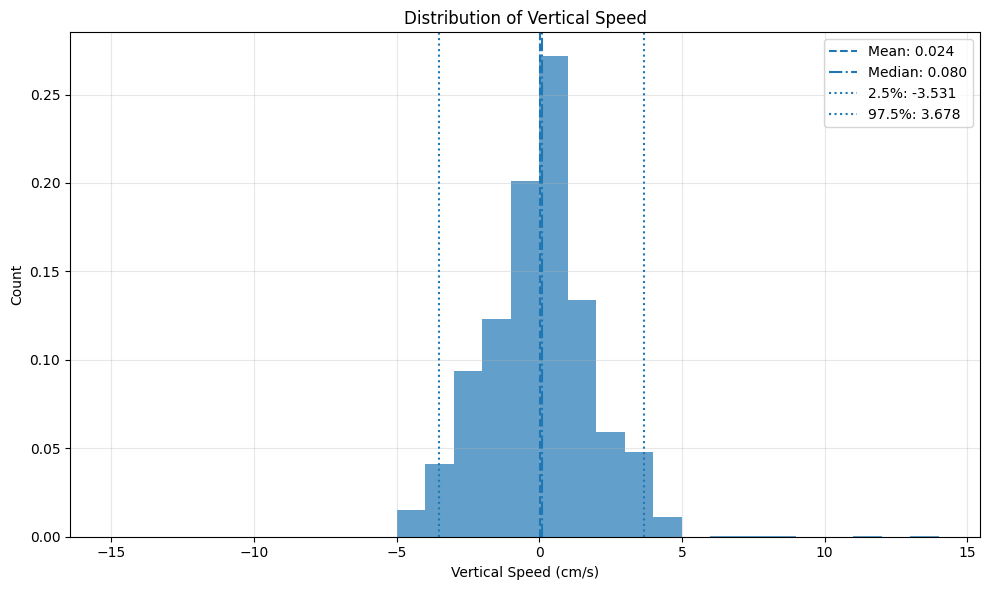

In [49]:
vs = dzdt[sel]-vert_speed[sel]
# Remove NaNs
vs = vs[~np.isnan(vs)]

# --- Statistics ---
mean_vs = np.mean(vs)
median_vs = np.median(vs)
p_low, p_high = np.percentile(vs, [2.5, 97.5])

# --- Plot ---
plt.figure(figsize=(10, 6))

plt.hist(vs, bins=np.arange(-15,15,1), alpha=0.7, density = True)

# Mean & median
plt.axvline(mean_vs, linestyle="--", label=f"Mean: {mean_vs:.3f}")
plt.axvline(median_vs, linestyle="-.", label=f"Median: {median_vs:.3f}")

# 95% interval
plt.axvline(p_low, linestyle=":", label=f"2.5%: {p_low:.3f}")
plt.axvline(p_high, linestyle=":", label=f"97.5%: {p_high:.3f}")

plt.xlabel("Vertical Speed (cm/s)")
plt.ylabel("Count")
plt.title("Distribution of Vertical Speed")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
### original parameters
fm.params.abs_compress = 4.1e-06
fm.params.therm_exp=7.05e-05
vol = fm.compute_volume(ds)
density = fm.compute_density(ds)
buoyancy = fm.compute_buoyancy_force(density=density,vol=vol)/9.81
## now change parameters to optimize and see how buoyancy changes
fm.params.abs_compress = 5.8e-06
vol2 = fm.compute_volume(ds)
buoyancy2 = fm.compute_buoyancy_force(density=density,vol=vol2)/9.81
fm.params.abs_compress = 4.1e-06
fm.params.therm_exp= 1e-04
vol3 = fm.compute_volume(ds)
buoyancy3 = fm.compute_buoyancy_force(density=density,vol=vol3)/9.81
fm.params.abs_compress = 5.8e-06
fm.params.therm_exp= 1e-04
vol4 = fm.compute_volume(ds)
buoyancy4 = fm.compute_buoyancy_force(density=density,vol=vol4)/9.81

In [43]:
c_vbd = ds['C_VBD'].values
press = ds['PRES'].values
temp = ds['TEMP'].values
vol0 = (fm.params.volmax + (c_vbd - fm.params.vbd_min_cnts) / fm.params.vbd_cnts_per_cc) * np.exp(-fm.params.abs_compress * press + fm.params.therm_exp * (temp - fm.params.temp_ref))


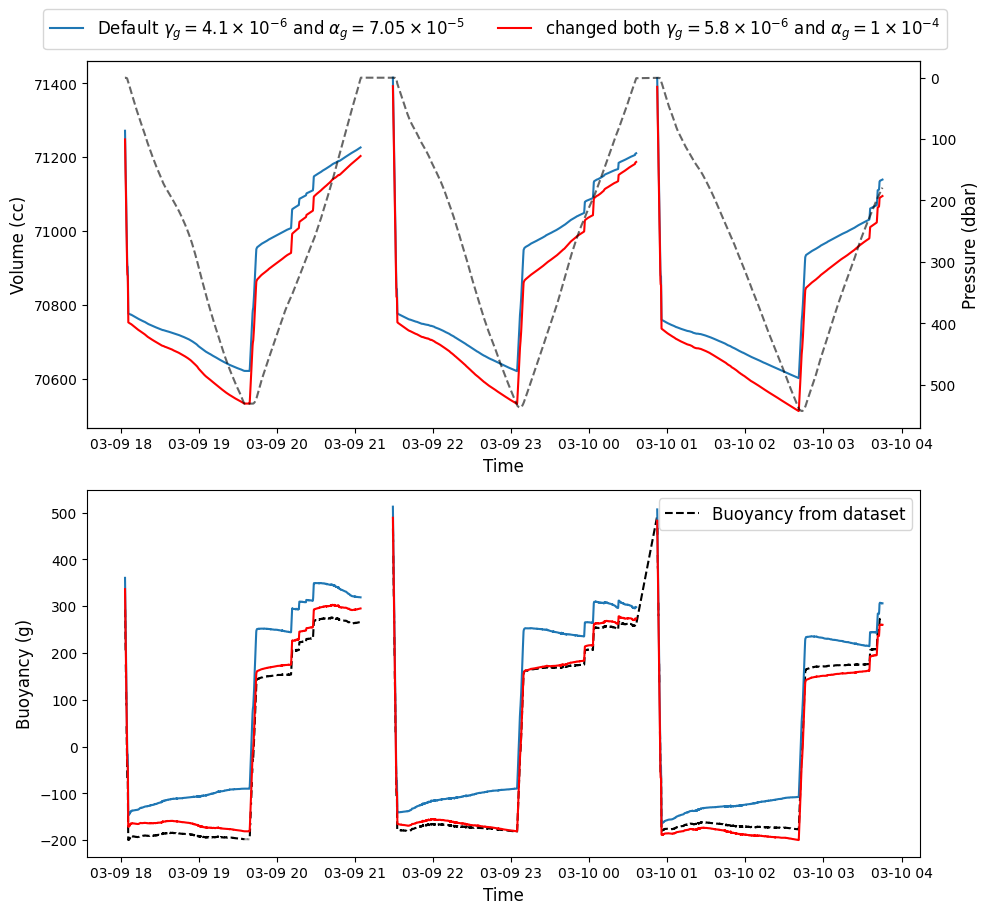

In [44]:
fig, ax = plt.subplots(2,1,figsize=(10, 9))
sel = slice(201890, 210000)
time = ds['TIME'][sel]

ax1_twin = ax[0].twinx()
ax1_twin.plot(time, ds['PRES'][sel], color='black', ls = "--", alpha=0.6, label='Pressure (dbar)')
ax1_twin.set_ylabel('Pressure (dbar)', color='black', fontsize=12)
ax1_twin.invert_yaxis()
#ax2_twin = ax[0].twinx()
#ax2_twin.plot(time, density[sel], color='red', ls = "--", alpha=0.6, label='Density (kg/m3)')
#ax2_twin.set_ylabel('Density (kg/m3)', color='red')
#ax2_twin.spines['right'].set_position(('outward', 60))  # Move second y-axis outwards
ax[0].plot(time, vol[sel], label=r"Default $\gamma_g = 4.1 \times 10^{-6}$ and $\alpha_g = 7.05\times 10^{-5}$")
#ax[0].plot(time, vol2[sel], label=r"changed only $\gamma_g$")
#ax[0].plot(time, vol3[sel], label=r"changed only $\alpha_g$")
ax[0].plot(time, vol4[sel], label=r"changed both $\gamma_g = 5.8\times 10^{-6}$ and $\alpha_g = 1\times 10^{-4}$", color = "red")
#ax[0].set_title('Volume of Glider over Time')
ax[0].set_xlabel('Time', fontsize=12)
ax[0].set_ylabel('Volume (cc)', fontsize=12)
#ax[0].plot(time, vol0[sel], label=r"$V_0$", color = "black", ls = "--")
#ax[0].legend(fontsize=12,ncol=3)

ax[1].plot(time, ds['BUOYANCY'][sel], label=r'Buoyancy from dataset', color = "black", ls = "--")
ax[1].plot(time, buoyancy[sel]*1000)
#ax[1].plot(time, buoyancy2[sel]*1000, label=r'Changed only $\gamma_g = 5.8\times 10^{-6}$')
#ax[1].plot(time, buoyancy3[sel]*1000, label=r'Changed only $\alpha_g = 1\times 10^{-4}$')
ax[1].plot(time, buoyancy4[sel]*1000, color = "red")
#ax[1].set_title('Buoyancy Force over Time')
ax[1].set_xlabel('Time', fontsize=12)
ax[1].set_ylabel('Buoyancy (g)', fontsize=12)
### make two lines for the legend
ax[1].legend(fontsize=12,ncol=3)
handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,          # 2 columns -> 2 rows for 4 entries
    fontsize=12
)

plt.tight_layout(rect=[0, 0, 1, 0.97])  # leave room for legend
plt.show()